In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/cic-ids1/CIC-IDS2017.csv


In [2]:
df = pd.read_csv('/kaggle/input/cic-ids1/CIC-IDS2017.csv')
df

,Flow ID,Source IP,Source Port,Destination IP,Destination Port,Protocol,Timestamp,Flow Duration,Total Fwd Packets,Total Backward Packets,...,min_seg_size_forward,Active Mean,Active Std,Active Max,Active Min,Idle Mean,Idle Std,Idle Max,Idle Min,Label
0,192.168.10.50-207.210.46.249-123-123-17,192.168.10.50,123.0,207.210.46.249,123.0,17.0,03/07/2017 10:21:51,26325.0,1.0,1.0,...,32.0,0.000000e+00,0.000000e+00,0.0,0.0,0.000000e+00,0.000000,0.0,0.0,BENIGN
1,152.163.66.131-192.168.10.16-443-56372-6,192.168.10.16,56372.0,152.163.66.131,443.0,6.0,03/07/2017 11:31:29,28470.0,1.0,1.0,...,20.0,0.000000e+00,0.000000e+00,0.0,0.0,0.000000e+00,0.000000,0.0,0.0,BENIGN
2,192.168.10.17-23.194.141.180-44272-443-6,192.168.10.17,44272.0,23.194.141.180,443.0,6.0,5/7/2017 3:33,29409364.0,31.0,31.0,...,32.0,1.495010e+06,2.081936e+06,2967161.0,22859.0,1.000000e+07,15092.487140,10000000.0,10000000.0,BENIGN
3,192.168.10.3-192.168.10.16-53-36457-17,192.168.10.16,36457.0,192.168.10.3,53.0,17.0,03/07/2017 04:43:35,122544.0,2.0,2.0,...,32.0,0.000000e+00,0.000000e+00,0.0,0.0,0.000000e+00,0.000000,0.0,0.0,BENIGN
4,192.168.10.3-192.168.10.5-53-58564-17,192.168.10.5,58564.0,192.168.10.3,53.0,17.0,5/7/2017 3:13,18131940.0,4.0,4.0,...,20.0,1.560000e+02,0.000000e+00,156.0,156.0,1.810000e+07,0.000000,18100000.0,18100000.0,BENIGN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3119340,192.168.10.3-192.168.10.19-53-35297-17,192.168.10.19,35297.0,192.168.10.3,53.0,17.0,5/7/2017 11:27,215.0,2.0,2.0,...,32.0,0.000000e+00,0.000000e+00,0.0,0.0,0.000000e+00,0.000000,0.0,0.0,BENIGN
3119341,192.168.10.16-52.86.47.42-59644-443-6,52.86.47.42,443.0,192.168.10.16,59644.0,6.0,4/7/2017 3:17,42.0,1.0,1.0,...,32.0,0.000000e+00,0.000000e+00,0.0,0.0,0.000000e+00,0.000000,0.0,0.0,BENIGN
3119342,192.168.10.3-192.168.10.8-53-50859-17,192.168.10.8,50859.0,192.168.10.3,53.0,17.0,4/7/2017 2:40,61611.0,2.0,2.0,...,20.0,0.000000e+00,0.000000e+00,0.0,0.0,0.000000e+00,0.000000,0.0,0.0,BENIGN
3119343,192.168.10.8-23.21.212.138-54558-80-6,192.168.10.8,54558.0,23.21.212.138,80.0,6.0,5/7/2017 1:46,61005308.0,12.0,15.0,...,20.0,5.541967e+04,2.115952e+04,98611.0,46699.0,9.990895e+06,4274.844917,9993883.0,9983838.0,BENIGN


In [3]:
df = df.rename(columns={col: col.strip() for col in df.columns})

In [4]:
data = df

remove_features = ['Flow ID', 'Source IP', 'Source Port', 'Destination IP', 'Destination Port', 'Timestamp', 'Fwd Packet Length Max', 'Fwd Packet Length Min', 'Fwd Packet Length Mean', 'Fwd Packet Length Std', 'Bwd Packet Length Max', 'Bwd Packet Length Min', 'Bwd Packet Length Mean', 'Bwd Packet Length Std', 'Flow IAT Mean', 'Flow IAT Std', 'Flow IAT Max', 'Flow IAT Min', 'Fwd IAT Mean', 'Fwd IAT Std', 'Fwd IAT Max', 'Fwd IAT Min', 'Bwd IAT Mean', 'Bwd IAT Std', 'Bwd IAT Max', 'Bwd IAT Min', 'Packet Length Mean', 'Packet Length Std', 'Packet Length Variance', 'Fwd Header Length.1', 'Active Mean', 'Active Std', 'Active Max', 'Active Min', 'Idle Mean', 'Idle Std', 'Idle Max', 'Idle Min',]
df.drop(columns=remove_features, inplace=True)
df.shape

(3119345, 47)

In [5]:
info = df.describe()
all_zero = info.loc[:,(info.iloc[1:] == 0).all()]
all_zero

,Bwd PSH Flags,Bwd URG Flags,Fwd Avg Bytes/Bulk,Fwd Avg Packets/Bulk,Fwd Avg Bulk Rate,Bwd Avg Bytes/Bulk,Bwd Avg Packets/Bulk,Bwd Avg Bulk Rate
count,2830743.0,2830743.0,2830743.0,2830743.0,2830743.0,2830743.0,2830743.0,2830743.0
mean,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
std,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
min,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
25%,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
50%,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
75%,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
max,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [6]:


df.drop(columns=all_zero, inplace=True)
df.shape 



(3119345, 39)

In [7]:
df.drop_duplicates(inplace=True)
df.shape

(2219258, 39)

In [8]:
for i in df.columns:
    df = df[df[i] != "Infinity"]
    df = df[df[i] != np.nan]
    df = df[df[i] != ",,"]

df[~df.isna()]

df.shape

(2219258, 39)

In [9]:
df.groupby('Label').first()

,Protocol,Flow Duration,Total Fwd Packets,Total Backward Packets,Total Length of Fwd Packets,Total Length of Bwd Packets,Flow Bytes/s,Flow Packets/s,Fwd IAT Total,Bwd IAT Total,...,Avg Fwd Segment Size,Avg Bwd Segment Size,Subflow Fwd Packets,Subflow Fwd Bytes,Subflow Bwd Packets,Subflow Bwd Bytes,Init_Win_bytes_forward,Init_Win_bytes_backward,act_data_pkt_fwd,min_seg_size_forward
Label,,,,,,,,,,,,,,,,,,,,,
BENIGN,17.0,26325.0,1.0,1.0,48.0,48.0,3646.723647,75.973409,0.0,0.0,...,48.000000,48.000000,1.0,48.0,1.0,48.0,-1.0,-1.0,0.0,32.0
Bot,6.0,129121.0,4.0,3.0,210.0,134.0,2664.167719,54.212715,129121.0,127757.0,...,52.500000,44.666667,4.0,210.0,3.0,134.0,8192.0,237.0,3.0,20.0
DDoS,6.0,8548127.0,4.0,0.0,24.0,0.0,2.807633,0.467939,8548127.0,0.0,...,6.000000,0.000000,4.0,24.0,0.0,0.0,256.0,-1.0,3.0,20.0
DoS GoldenEye,6.0,5003910.0,4.0,5.0,357.0,3525.0,775.793330,1.798593,2748.0,5003775.0,...,89.250000,705.000000,4.0,357.0,5.0,3525.0,29200.0,235.0,1.0,32.0
DoS Hulk,6.0,97463530.0,7.0,6.0,359.0,11595.0,122.651006,0.133383,97500000.0,1305.0,...,51.285714,1932.500000,7.0,359.0,6.0,11595.0,251.0,235.0,2.0,20.0
DoS Slowhttptest,6.0,63144919.0,7.0,0.0,0.0,0.0,0.000000,0.110856,63100000.0,0.0,...,0.000000,0.000000,7.0,0.0,0.0,0.0,29200.0,-1.0,0.0,40.0
DoS slowloris,6.0,3001291.0,3.0,0.0,0.0,0.0,0.000000,0.999570,3001291.0,0.0,...,0.000000,0.000000,3.0,0.0,0.0,0.0,29200.0,-1.0,0.0,40.0
FTP-Patator,6.0,48.0,2.0,0.0,14.0,0.0,291666.666700,41666.666670,48.0,0.0,...,7.000000,0.000000,2.0,14.0,0.0,0.0,229.0,-1.0,0.0,32.0
Heartbleed,6.0,119262215.0,2792.0,2110.0,13712.0,7878135.0,66172.232340,41.102708,119000000.0,119000000.0,...,4.911175,3733.713270,2792.0,13712.0,2110.0,7878135.0,235.0,235.0,120.0,32.0


In [10]:
df.dropna(inplace=True)
df.shape

(2219019, 39)

In [11]:
df.reset_index(drop=True, inplace=True)

In [12]:
import pandas as pd
import numpy as np
from imblearn.under_sampling import RandomUnderSampler
from sklearn.model_selection import train_test_split
from sklearn import svm
from sklearn.ensemble import RandomForestClassifier
import xgboost as xgb
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Conv2D, MaxPooling2D, Flatten, Dropout, BatchNormalization, ZeroPadding2D
from sklearn.metrics import accuracy_score
from sklearn.metrics import classification_report
from sklearn.neighbors import NearestNeighbors
from sklearn.cluster import KMeans
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

In [13]:
minority_class = ['Web Attack – Sql Injection', 'Infiltration', 'Web Attack – XSS']
majority_class = ['BENIGN', 'DoS Hulk', 'DDoS', 'PortScan', 'Web Attack – Brute Force', 'Bot', 'DoS Slowhttptest', 'DoS slowloris', 'FTP-Patator', 'SSH-Patator', 'DoS GoldenEye']

# Split the dataset into minority and majority
minority = df[df['Label'].isin(minority_class)].reset_index(drop=True)
majority = df[df['Label'].isin(majority_class)].reset_index(drop=True)
     

In [14]:
majority.replace([np.inf, -np.inf], np.nan, inplace=True)
majority.dropna(inplace=True)  # Drop rows with NaN values


In [15]:
enn = NearestNeighbors(n_neighbors=500)
enn.fit(majority.drop(columns=['Label']))
difficult_idx = enn.kneighbors(minority.drop(columns=['Label']), return_distance=False).flatten()
difficult = df.iloc[difficult_idx]
easy = df.reset_index(drop=True).drop(difficult_idx)

In [16]:
difficult.replace([np.inf, -np.inf], np.nan, inplace=True)
difficult.dropna(inplace=True)

# Now, you can fit the KMeans model
kmeans = KMeans(n_clusters=100)
kmeans.fit(difficult.drop(columns=['Label']))

compressed = pd.DataFrame(kmeans.cluster_centers_, columns=difficult.columns[:-1])
compressed['Label'] = 'BENIGN'


In [17]:
# Generate synthetic minority samples in the difficult set
difficult_min = difficult[difficult['Label'].isin(minority_class)]
difficult_max = difficult[difficult['Label'] == 'BENIGN']
difficult_range = difficult_max - difficult_min
difficult_samples = pd.DataFrame()

In [18]:


for i in range(10):
  r = pd.DataFrame(columns=difficult_min.columns[:-1])
  random_values = np.random.rand(difficult_min.shape[1]-1)
  r.loc[0] = random_values
  dm = difficult_min.iloc[:,:-1]
  sample = dm.add(r, fill_value=0)
  sample['Label'] = minority_class[np.random.randint(0, len(minority_class))]
  difficult_samples = pd.concat([difficult_samples, sample], ignore_index=True)
     



In [19]:
new_train_set = pd.concat([easy, compressed, difficult_min, difficult_samples])
df2 = new_train_set.sample(frac=1).reset_index(drop=True)
     

df2
     


,Protocol,Flow Duration,Total Fwd Packets,Total Backward Packets,Total Length of Fwd Packets,Total Length of Bwd Packets,Flow Bytes/s,Flow Packets/s,Fwd IAT Total,Bwd IAT Total,...,Avg Bwd Segment Size,Subflow Fwd Packets,Subflow Fwd Bytes,Subflow Bwd Packets,Subflow Bwd Bytes,Init_Win_bytes_forward,Init_Win_bytes_backward,act_data_pkt_fwd,min_seg_size_forward,Label
0,17.0,69588.0,2.0,2.0,88.0,352.0,6322.929241,57.481175,1.0,1.0,...,176.000000,2.0,88.0,2.0,352.0,-1.0,-1.0,1.0,32.0,BENIGN
1,6.0,102372286.0,39.0,35.0,2722.0,20472.0,226.565225,0.722852,102000000.0,93300000.0,...,584.914286,39.0,2722.0,35.0,20472.0,29200.0,65535.0,38.0,20.0,BENIGN
2,17.0,167570.0,2.0,2.0,92.0,162.0,1515.784448,23.870621,1.0,3.0,...,81.000000,2.0,92.0,2.0,162.0,-1.0,-1.0,1.0,32.0,BENIGN
3,6.0,118336024.0,25.0,19.0,2670.0,4482.0,60.438062,0.371823,118000000.0,113000000.0,...,235.894737,25.0,2670.0,19.0,4482.0,8192.0,385.0,24.0,20.0,BENIGN
4,17.0,60302.0,2.0,2.0,76.0,172.0,4112.633080,66.332792,3.0,49.0,...,86.000000,2.0,76.0,2.0,172.0,-1.0,-1.0,1.0,20.0,BENIGN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2205408,17.0,122716.0,1.0,1.0,49.0,154.0,1654.226018,16.297793,0.0,0.0,...,154.000000,1.0,49.0,1.0,154.0,-1.0,-1.0,0.0,20.0,BENIGN
2205409,17.0,65729.0,1.0,1.0,56.0,72.0,1947.390041,30.427969,0.0,0.0,...,72.000000,1.0,56.0,1.0,72.0,-1.0,-1.0,0.0,20.0,BENIGN
2205410,17.0,69883.0,2.0,2.0,78.0,120.0,2833.307099,57.238527,0.0,4.0,...,60.000000,2.0,78.0,2.0,120.0,-1.0,-1.0,1.0,32.0,BENIGN
2205411,6.0,115384079.0,20.0,17.0,758.0,3565.0,37.466174,0.320668,115384079.0,110454058.0,...,209.705882,20.0,758.0,17.0,3565.0,8192.0,980.0,19.0,20.0,BENIGN


In [20]:


X_train, X_test, y_train, y_test = train_test_split(df2.iloc[:,:-1], df2.iloc[:,-1], test_size=0.3, random_state=42)
     

to_remove = [x for x in y_test.unique() if x not in y_train.unique()]
rows_to_remove = y_test.isin(to_remove)

y_test = y_test[~rows_to_remove]
X_test = X_test[~rows_to_remove]
     

X_train.shape
     


(1543789, 38)

In [21]:
import numpy as np
from sklearn.preprocessing import StandardScaler

# Replace infinity with a large finite value
X_train.replace([np.inf, -np.inf], np.nan, inplace=True)
X_test.replace([np.inf, -np.inf], np.nan, inplace=True)

# Fill NaN (caused by infinity) with a large finite value
X_train.fillna(1e18, inplace=True)
X_test.fillna(1e18, inplace=True)

# Now, you can apply StandardScaler
scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [22]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()
y_train_encoded = le.fit_transform(y_train)
y_test_encoded = le.transform(y_test)
     

In [23]:
cl = len(df2["Label"].value_counts())
cl

17

In [24]:
import numpy as np
unique_labels = np.unique(y_train_encoded)
print(unique_labels)


[ 0  1  2  3  4  5  6  7  8  9 10 11 12 13 14 15 16]


In [25]:
X1_train = X_train.reshape((X_train.shape[0], 1, X_train.shape[1]))
X1_test = X_test.reshape((X_test.shape[0], 1, X_test.shape[1]))

from keras.models import Sequential
from keras.layers import Bidirectional, LSTM, Dropout, Dense

# Bidirectional LSTM
model = Sequential()
model.add(Bidirectional(LSTM(128, activation='tanh', return_sequences=True), input_shape=(X1_train.shape[1], X1_train.shape[2])))
model.add(Dropout(0.2))
model.add(Bidirectional(LSTM(64, activation='tanh')))
model.add(Dropout(0.2))
model.add(Dense(32, activation='LeakyReLU'))
model.add(Dropout(0.2))
model.add(Dense(17, activation='softmax'))

model.compile(optimizer='adam',
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])

model.fit(X1_train, y_train_encoded, epochs=10, validation_data=(X1_test, y_test_encoded))

results = model.evaluate(X1_test, y_test_encoded)
print("\n\nAccuracy: %.2f%%" % (results[1] * 100))


Epoch 1/10
48244/48244 [==============================] - 481s 10ms/step - loss: 0.0542 - accuracy: 0.9849 - val_loss: 0.0536 - val_accuracy: 0.9818
Epoch 2/10
48244/48244 [==============================] - 456s 9ms/step - loss: 0.0317 - accuracy: 0.9904 - val_loss: 0.0230 - val_accuracy: 0.9933
Epoch 3/10
48244/48244 [==============================] - 464s 10ms/step - loss: 0.0263 - accuracy: 0.9922 - val_loss: 0.0216 - val_accuracy: 0.9934
Epoch 4/10
48244/48244 [==============================] - 492s 10ms/step - loss: 0.0239 - accuracy: 0.9930 - val_loss: 0.0265 - val_accuracy: 0.9912
Epoch 5/10
48244/48244 [==============================] - 489s 10ms/step - loss: 0.0228 - accuracy: 0.9934 - val_loss: 0.0197 - val_accuracy: 0.9943
Epoch 6/10
48244/48244 [==============================] - 488s 10ms/step - loss: 0.0218 - accuracy: 0.9937 - val_loss: 0.0270 - val_accuracy: 0.9938
Epoch 7/10
48244/48244 [==============================] - 473s 10ms/step - loss: 0.0214 - accuracy: 0.9938 

In [26]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score

# Reshape data for Random Forest
X_train_rf = X1_train.reshape((X1_train.shape[0], X1_train.shape[2]))
X_test_rf = X1_test.reshape((X1_test.shape[0], X1_test.shape[2]))

# Create Random Forest model
rf_model = RandomForestClassifier(n_estimators=100, random_state=42)

# Train the model
rf_model.fit(X_train_rf, y_train_encoded)

# Predictions
y_pred_rf = rf_model.predict(X_test_rf)

# Evaluate the model
accuracy = accuracy_score(y_test_encoded, y_pred_rf)
print("\n\nAccuracy: %.2f%%" % (accuracy * 100))




Accuracy: 99.82%


In [27]:
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import accuracy_score

# Reshape data for MLP
X_train_mlp = X1_train.reshape((X1_train.shape[0], X1_train.shape[2]))
X_test_mlp = X1_test.reshape((X1_test.shape[0], X1_test.shape[2]))

# Create MLP model
mlp_model = MLPClassifier(random_state=42)

# Train the model
mlp_model.fit(X_train_mlp, y_train_encoded)

# Predictions
y_pred_mlp = mlp_model.predict(X_test_mlp)

# Evaluate the model
accuracy = accuracy_score(y_test_encoded, y_pred_mlp)
print("\n\nAccuracy: %.2f%%" % (accuracy * 100))




Accuracy: 99.58%


In [28]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score

# Reshape data for Decision Tree
X_train_dt = X1_train.reshape((X1_train.shape[0], X1_train.shape[2]))
X_test_dt = X1_test.reshape((X1_test.shape[0], X1_test.shape[2]))

# Create Decision Tree model
dt_model = DecisionTreeClassifier(random_state=42)

# Train the model
dt_model.fit(X_train_dt, y_train_encoded)

# Predictions
y_pred_dt = dt_model.predict(X_test_dt)

# Evaluate the model
accuracy = accuracy_score(y_test_encoded, y_pred_dt)
print("\n\nAccuracy: %.2f%%" % (accuracy * 100))




Accuracy: 99.75%


In [29]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score

# Create Random Forest model
rf_model = RandomForestClassifier(n_estimators=100, max_depth=10, random_state=42)

# Train the model
rf_model.fit(X_train, y_train_encoded)

# Predictions
y_pred_rf = rf_model.predict(X_test)

# Evaluate the model
accuracy = accuracy_score(y_test_encoded, y_pred_rf)
print("Accuracy: %.2f%%" % (accuracy * 100.0))


Accuracy: 99.54%


In [30]:
from sklearn.ensemble import AdaBoostClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score

# Create Decision Tree model (base estimator for AdaBoost)
base_model = DecisionTreeClassifier(max_depth=10, random_state=42)

# Create AdaBoost model
adaboost_model = AdaBoostClassifier(base_model, n_estimators=100, random_state=42)

# Train the model
adaboost_model.fit(X_train, y_train_encoded)

# Predictions
y_pred_adaboost = adaboost_model.predict(X_test)

# Evaluate the model
accuracy = accuracy_score(y_test_encoded, y_pred_adaboost)
print("Accuracy: %.2f%%" % (accuracy * 100.0))


Accuracy: 99.64%


In [31]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score

# Create Logistic Regression model
logreg_model = LogisticRegression(random_state=42)

# Train the model
logreg_model.fit(X_train, y_train_encoded)

# Predictions
y_pred_logreg = logreg_model.predict(X_test)

# Evaluate the model
accuracy = accuracy_score(y_test_encoded, y_pred_logreg)
print("Accuracy: %.2f%%" % (accuracy * 100.0))


Accuracy: 97.45%


In [32]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score

# Create k-Nearest Neighbors model
knn_model = KNeighborsClassifier(n_neighbors=5)  # You can adjust the number of neighbors (n_neighbors) as needed

# Train the model
knn_model.fit(X_train, y_train_encoded)

# Predictions
y_pred_knn = knn_model.predict(X_test)

# Evaluate the model
accuracy = accuracy_score(y_test_encoded, y_pred_knn)
print("Accuracy: %.2f%%" % (accuracy * 100.0))


Accuracy: 99.72%


In [33]:
unique_labels = le.transform(df2['Label'].unique())

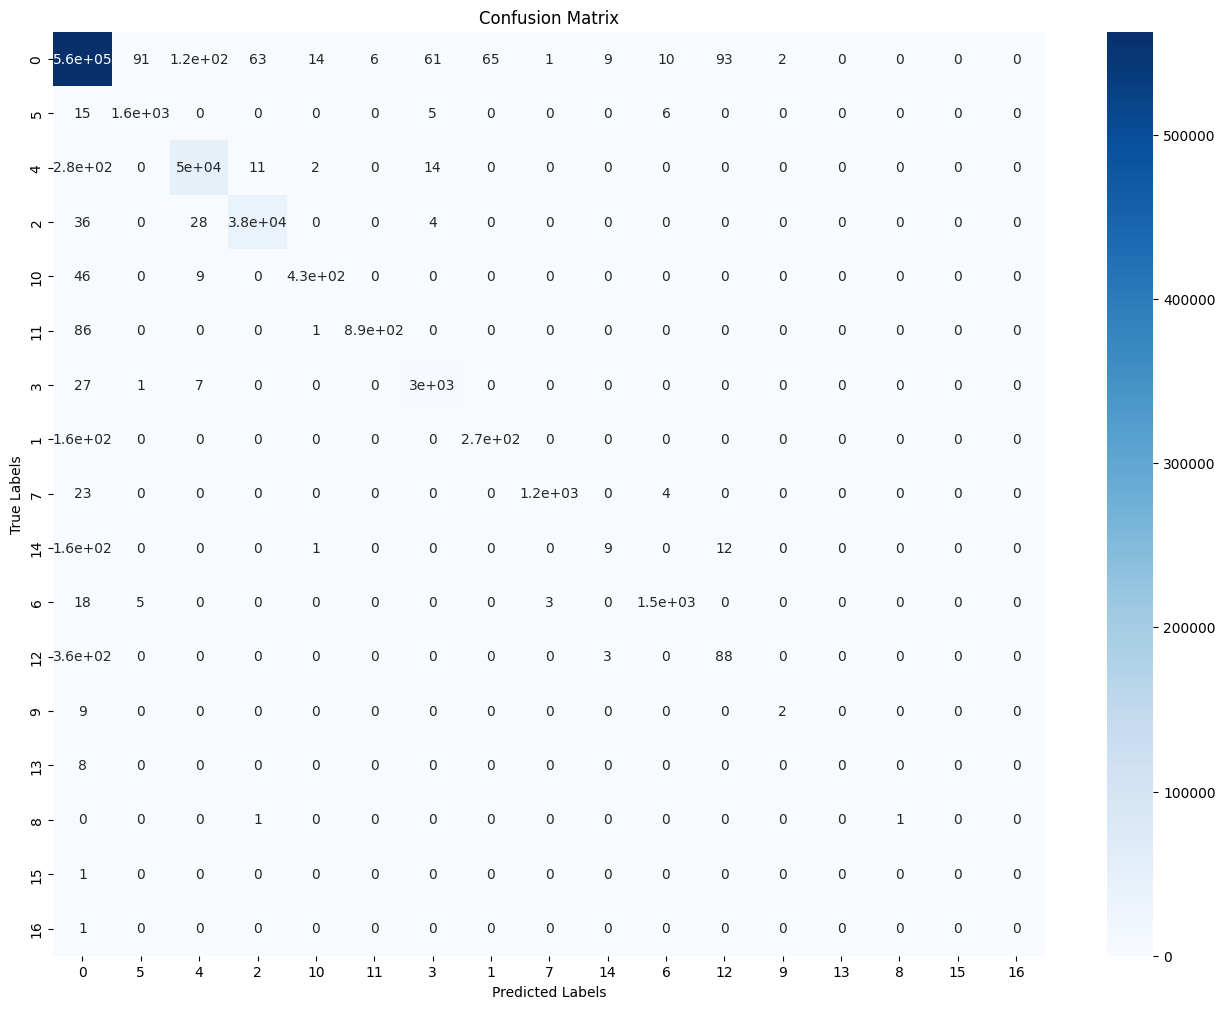

In [34]:
cm = confusion_matrix(y_test_encoded, y_pred_knn, labels=unique_labels)
fig, ax = plt.subplots(figsize=(16, 12))
sns.heatmap(cm, annot=True, cmap='Blues', xticklabels=unique_labels, yticklabels=unique_labels)

plt.xlabel("Predicted Labels")
plt.ylabel("True Labels")
plt.title("Confusion Matrix")

plt.show()

In [35]:
from sklearn.metrics import confusion_matrix



# Create the confusion matrix
confusion_matrix_knn = confusion_matrix(y_test_encoded, y_pred_knn)

# Print the confusion matrix or perform further analysis based on its values
print("Confusion Matrix:\n", confusion_matrix_knn)


Confusion Matrix:
 [[562777     65     63     61    118     91     10      1      0      2
      14      6     93      0      9      0      0]
 [   161    266      0      0      0      0      0      0      0      0
       0      0      0      0      0      0      0]
 [    36      0  38014      4     28      0      0      0      0      0
       0      0      0      0      0      0      0]
 [    27      0      0   2979      7      1      0      0      0      0
       0      0      0      0      0      0      0]
 [   282      0     11     14  50040      0      0      0      0      0
       2      0      0      0      0      0      0]
 [    15      0      0      5      0   1561      6      0      0      0
       0      0      0      0      0      0      0]
 [    18      0      0      0      0      5   1457      3      0      0
       0      0      0      0      0      0      0]
 [    23      0      0      0      0      0      4   1226      0      0
       0      0      0      0      0     

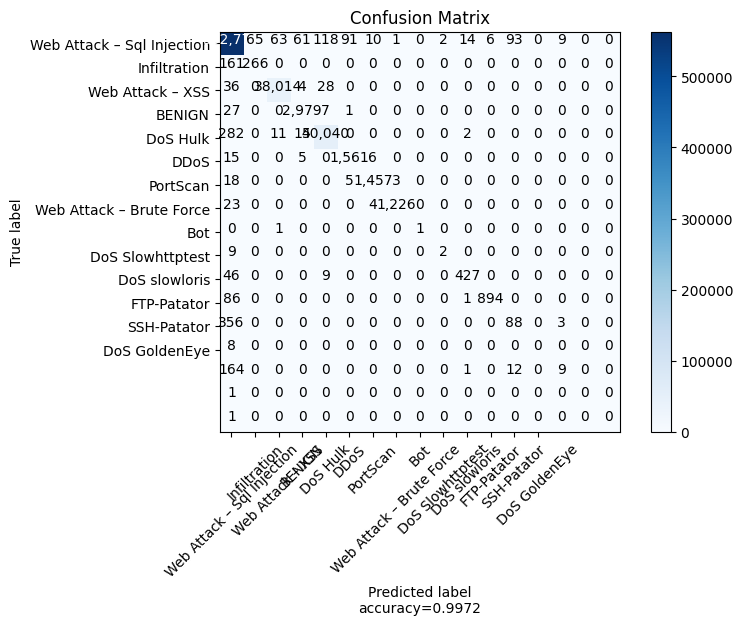

In [36]:
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, accuracy_score
import itertools

target_names = ['Web Attack – Sql Injection', 'Infiltration', 'Web Attack – XSS',
'BENIGN', 'DoS Hulk', 'DDoS', 'PortScan', 'Web Attack – Brute Force', 'Bot', 'DoS Slowhttptest', 'DoS slowloris', 'FTP-Patator', 'SSH-Patator', 'DoS GoldenEye']

conf_matrix = confusion_matrix(y_test_encoded, y_pred_knn)

def plot_confusion_matrix(cm, target_names, title='Confusion Matrix', cmap=None, normalize=True):
# Plot Confusion Matrixm, target_names, title='Confusion Matrix', cmap=None, normalize=True):
    if cmap is None:
        cmap = plt.get_cmap('Blues')
    plt.figure(figsize=(8, 6))
    plt.imshow(cm, interpolation='nearest', cmap=cmap)
    plt.title(title)
    plt.colorbar()

    if target_names is not None:
        tick_marks = np.arange(len(target_names))
        plt.xticks(tick_marks, target_names, rotation=45)
        plt.yticks(tick_marks, target_names)

    if normalize:
        cm = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]

    thresh = cm.max() / 1.5 if normalize else cm.max() / 2
    for i, j in itertools.product(range(cm.shape[0]), range(cm.shape[1])):
        if normalize:
            plt.text(j, i, "{:0.4f}".format(cm[i, j]),
                     horizontalalignment="center",
                     color="white" if cm[i, j] > thresh else "black")
        else:
            plt.text(j, i, "{:,}".format(cm[i, j]),
                     horizontalalignment="center",
                     color="white" if cm[i, j] > thresh else "black")

    plt.tight_layout()
    plt.ylabel('True label')
    plt.xlabel('Predicted label\naccuracy={:0.4f}'.format(accuracy))
    plt.show()

plot_confusion_matrix(cm=conf_matrix, target_names=target_names, title="Confusion Matrix", normalize=False)

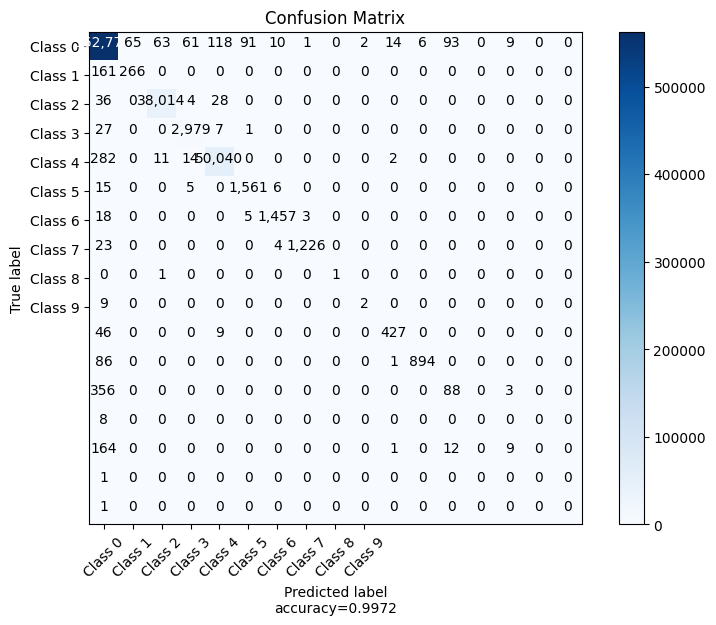

In [37]:
conf_matrix = confusion_matrix(y_test_encoded, y_pred_knn)

# Plot Confusion Matrix
def plot_confusion_matrix(cm, target_names, title='Confusion Matrix', cmap=None, normalize=True):
    if cmap is None:
        cmap = plt.get_cmap('Blues')
    plt.figure(figsize=(8, 6))
    plt.imshow(cm, interpolation='nearest', cmap=cmap)
    plt.title(title)
    plt.colorbar()

    if target_names is not None:
        tick_marks = np.arange(len(target_names))
        plt.xticks(tick_marks, target_names, rotation=45)
        plt.yticks(tick_marks, target_names)

    if normalize:
        cm = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]

    thresh = cm.max() / 1.5 if normalize else cm.max() / 2
    for i, j in itertools.product(range(cm.shape[0]), range(cm.shape[1])):
        if normalize:
            plt.text(j, i, "{:0.4f}".format(cm[i, j]),
                     horizontalalignment="center",
                     color="white" if cm[i, j] > thresh else "black")
        else:
            plt.text(j, i, "{:,}".format(cm[i, j]),
                     horizontalalignment="center",
                     color="white" if cm[i, j] > thresh else "black")

    plt.tight_layout()
    plt.ylabel('True label')
    plt.xlabel('Predicted label\naccuracy={:0.4f}'.format(accuracy))
    plt.show()

# Assuming 10 classes, replace with your actual class names
target_names = ['Class 0', 'Class 1', 'Class 2', 'Class 3', 'Class 4', 'Class 5', 'Class 6', 'Class 7', 'Class 8', 'Class 9']
plot_confusion_matrix(cm=conf_matrix, target_names=target_names, title="Confusion Matrix", normalize=False)

In [38]:
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import accuracy_score

# Create Gaussian Naive Bayes model
nb_model = GaussianNB()

# Train the model
nb_model.fit(X_train, y_train_encoded)

# Predictions
y_pred_nb = nb_model.predict(X_test)

# Evaluate the model
accuracy = accuracy_score(y_test_encoded, y_pred_nb)
print("Accuracy: %.2f%%" % (accuracy * 100.0))


Accuracy: 53.58%
